<a href="https://colab.research.google.com/github/anyjamesokay/ugradthesis/blob/main/ThesisColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [3]:
!apt-get update -qq
!apt-get install -y libgsl-dev

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgsl27 libgslcblas0
Suggested packages:
  gsl-ref-psdoc | gsl-doc-pdf | gsl-doc-info | gsl-ref-html
The following NEW packages will be installed:
  libgsl-dev libgsl27 libgslcblas0
0 upgraded, 3 newly installed, 0 to remove and 28 not upgraded.
Need to get 2,349 kB of archives.
After this operation, 10.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 libgslcblas0 amd64 2.7.1+dfsg-6ubuntu2 [104 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble/universe amd64 libgsl27 amd64 2.7.1+dfsg-6ubuntu2 [987 kB]
Get:3 http://archive.ubuntu.com/ubuntu noble/universe amd64 libgsl-dev amd64 2.7.1+dfsg-6ubuntu2 

In [4]:
!pip install gwosc gwpy pycbc corner sxs fastemriwaveforms teobresums gw-eccentricity scri

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.8/239.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.0/382.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.5/149.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.6/168.6 kB 10.8 MB/s e

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import EOBRun_module as EOB
import sxs
import gw_eccentricity as egw

In [6]:
# SXS catalog experimentation
sxs.write_config(download=True, cache=True)
sxstest = sxs.load('SXS:BBH:1372')
h = sxstest.h
past_junkindex = h.index_closest_to(sxstest.metadata.reference_time)
#h = h[past_junkindex:]
t1 = h.t
h_22 = h[:, h.index(2, 2)]
h_33 = h[:, h.index(3, 3)]
h_44 = h[:, h.index(4, 4)]
A = h_22.abs
t_merger = t1[np.argmax(A)]
t01 = t1 - t_merger
# plt.plot(t01, h_22)

Loading SXS simulations using latest tag 'v3.0.0', published at 2025-05-14T18:17:30Z.


  0%|          | 0/5589954 [00:00<?, ?it/s]

  0%|          | 0/3105258 [00:00<?, ?it/s]

In [21]:
def ecxxmaker(t0, theta, mode, window, showpoints):
    def ec22(fplus, fminus):
      iksi = (abs(fplus - fminus))/(fplus + fminus)
      psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
      e_c = np.cos(psi) - np.sqrt(3)*np.sin(psi)
      return e_c

    def ec33(fplus, fminus):
      iksi = (abs(fplus - fminus))/(fplus + fminus)
      theta = (1/3)*np.arctan((1242*np.sqrt(3)/iksi)*(np.sqrt(35266176 - 31184003*iksi**2 - 3675129*iksi**4)/(15712542 + 1225043*iksi**2)))
      return (1/138)*(-107*iksi + np.sqrt(54648 + 11449*iksi)*np.cos(theta)-np.sqrt(163944 + 34347*iksi)*np.sin(theta))

    def ec44func(e):
      return (2*e*(6944-5700*e**2+261*e**4))/(8192-1513*e**2-3669*e**4)

    dt = abs(t0[1] - t0[0])
    #dtheta_dt = -sp.signal.savgol_filter(theta, window_length=100, polyorder=5, deriv=1, delta=dt)
    dtheta_dt = -np.gradient(theta, t0)
    dtheta_dt = sp.signal.savgol_filter(dtheta_dt, window_length=window, polyorder=3, delta=dt)
    fvalues = dtheta_dt / (2 * np.pi)
    #dfvalues = sp.signal.savgol_filter(fvalues, window_length=175, polyorder=3, deriv=1, delta=dt)
    dfvalues = np.gradient(fvalues, t0)
    dfvalues = sp.signal.savgol_filter(dfvalues, window_length=window, polyorder=3, delta=dt)
    zero_crossings = np.where(dfvalues[1:] * dfvalues[:-1] < 0)[0]
    zero_crossings2 = np.roll(zero_crossings, shift=1)
    zero_crossings3 = np.average(np.array([zero_crossings, zero_crossings2]), axis=0).astype(int)
    fplus = fvalues[zero_crossings]
    fminus = fvalues[zero_crossings2]
    iksi = (abs(fplus - fminus))/(fplus + fminus)
    if mode == 22:
      ee = ec22(fplus, fminus)
    elif mode == 33:
      ee = ec33(fplus, fminus)
    elif mode == 44:
      def ec44(e, iksi):
          return ec44func(e) - iksi
      ee = np.array([sp.optimize.root_scalar(ec44, args=(j,), x0=0.2, xtol = 1e-10).root for j in iksi])
    else: return 0

    timec = t0[zero_crossings3]
    ec_top = ee[1:-1:2]
    ec_bot = ee[2::2]
    timec_top = timec[1:-1:2]
    timec_bot = timec[2::2]
    ec_ave = np.average(np.array([ec_top, ec_bot]), axis =0)
    time_ave = np.average(np.array([timec_top, timec_bot]), axis =0)
    if showpoints: return timec_top, timec_bot, ec_top, ec_bot, time_ave, ec_ave
    else: return time_ave, ec_ave

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

/tmp/ipykernel_2892/4016233564.py:4: RuntimeWarning: invalid value encountered in sqrt
  psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
/tmp/ipykernel_2892/4016233564.py:10: RuntimeWarning: invalid value encountered in sqrt
  theta = (1/3)*np.arctan((1242*np.sqrt(3)/iksi)*(np.sqrt(35266176 - 31184003*iksi**2 - 3675129*iksi**4)/(15712542 + 1225043*iksi**2)))


Text(0.5, 1.0, 'SXS:BBH:1372')

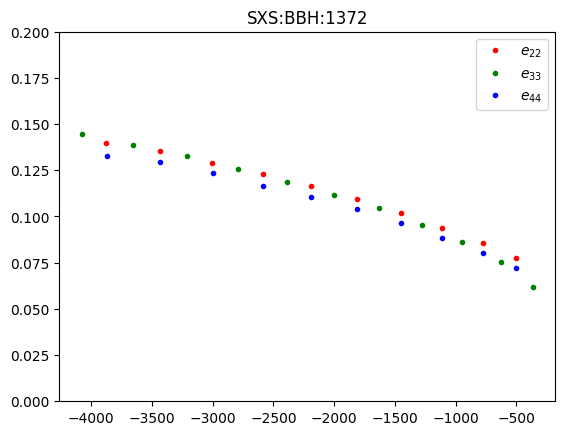

In [22]:
theta_22 = h_22.arg_unwrapped
theta_33 = h_33.arg_unwrapped
theta_44 = h_44.arg_unwrapped
theta_22 = theta_22 - theta_22[np.argmax(A)]
theta_33 = theta_33 - theta_33[np.argmax(A)]
theta_44 = theta_44 - theta_44[np.argmax(A)]

t22, ec22 = ecxxmaker(t01, theta_22.data, 22, 300, False)
t33, ec33 = ecxxmaker(t01, theta_33.data, 33, 300, False)
t44, ec44 = ecxxmaker(t01, theta_44.data, 44, 300, False)
t22 = t22[:10]; ec22 = ec22[:10]
t33 = t33[:11]; ec33 = ec33[:11]
t44 = t44[1:11]; ec44 = ec44[1:11]
plt.plot(t22, ec22, 'r.', label=r"$e_{22}$")
plt.plot(t33, ec33, 'g.', label=r"$e_{33}$")
plt.plot(t44, ec44, 'b.', label=r"$e_{44}$")
# plt.xlim(-3000, 0)
plt.ylim(0, 0.2)
plt.legend()
plt.title("SXS:BBH:1372")

Text(0.5, 1.0, 'SXS:BBH:1372')

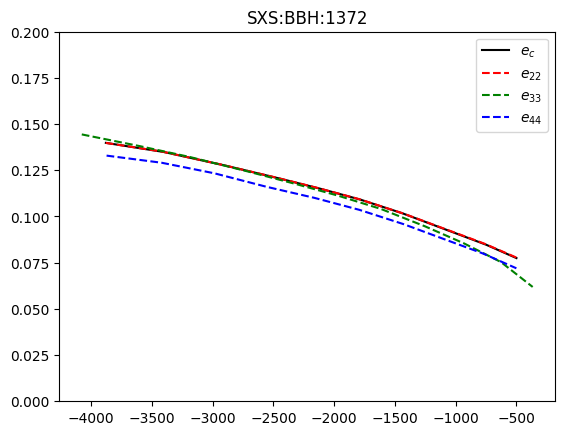

In [26]:
E_flux22 = abs(np.gradient(h_22, t01))**2
E_flux33 = abs(np.gradient(h_33, t01))**2
E_flux44 = abs(np.gradient(h_44, t01))**2
ec22interp = np.interp(t01, t22, ec22)
ec33interp = np.interp(t01, t33, ec33)
ec44interp = np.interp(t01, t44, ec44)

e_c = (ec22interp*E_flux22 + ec33interp*E_flux33 + ec44interp*E_flux44)/(E_flux22 + E_flux33 + E_flux44)
plt.plot(t01[find_nearest(t01, t22[0]):find_nearest(t01, t22[-1])], e_c[find_nearest(t01, t22[0]):find_nearest(t01, t22[-1])], 'k', label=r"$e_c$")
plt.plot(t01[find_nearest(t01, t22[0]):find_nearest(t01, t22[-1])], ec22interp[find_nearest(t01, t22[0]):find_nearest(t01, t22[-1])], 'r--', label=r"$e_{22}$")
plt.plot(t01[find_nearest(t01, t33[0]):find_nearest(t01, t33[-1])], ec33interp[find_nearest(t01, t33[0]):find_nearest(t01, t33[-1])], 'g--', label=r"$e_{33}$")
plt.plot(t01[find_nearest(t01, t44[0]):find_nearest(t01, t44[-1])], ec44interp[find_nearest(t01, t44[0]):find_nearest(t01, t44[-1])], 'b--', label=r"$e_{44}$")
# plt.xlim(-3000, 0)
plt.ylim(0, 0.2)
plt.legend()
plt.title('SXS:BBH:1372')

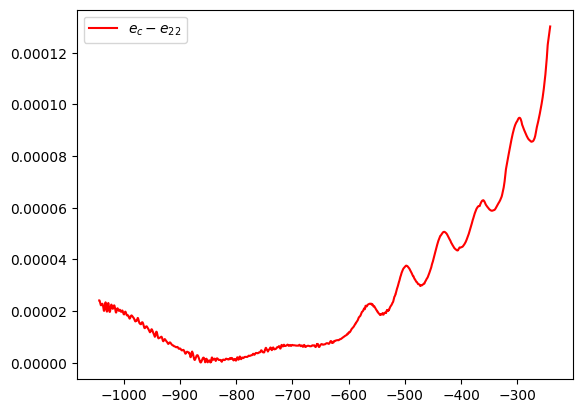

In [31]:
plt.plot(t01[find_nearest(t01, t22[0]):find_nearest(t01, t22[-1])], abs(e_c[find_nearest(t01, t22[0]):find_nearest(t01, t22[-1])]-ec22interp[find_nearest(t01, t22[0]):find_nearest(t01, t22[-1])]), color="red", label=r'$e_c-e_{22}$')
plt.legend()

SXS:BBH:3726. This contains 8.4 orbits, has $e_{ref} \approx 0.27$, and is highly precessing with significant $\chi$ values. Sounds good for a test.

In [27]:
sxs3726 = sxs.load('SXS:BBH:3726')
h3726 = sxs3726.h
h_copr = h3726.to_coprecessing_frame() # Following https://doi.org/10.48550/arXiv.2507.08345

# First we try with the original waveform, and compare with the coprecessing frame waveform.
past_junkindex = h3726.index_closest_to(sxstest.metadata.reference_time)
# h3726 = h3726[past_junkindex:]
t1 = h3726.t
h_22 = h3726[:, h3726.index(2, 2)]
h_33 = h3726[:, h3726.index(3, 3)]
h_44 = h3726[:, h3726.index(4, 4)]
A = h_22.abs
t_merger = t1[np.argmax(A)]
t01 = t1 - t_merger

  0%|          | 0/3194070 [00:00<?, ?it/s]

/tmp/ipykernel_2892/4016233564.py:4: RuntimeWarning: invalid value encountered in sqrt
  psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
/tmp/ipykernel_2892/4016233564.py:10: RuntimeWarning: invalid value encountered in sqrt
  theta = (1/3)*np.arctan((1242*np.sqrt(3)/iksi)*(np.sqrt(35266176 - 31184003*iksi**2 - 3675129*iksi**4)/(15712542 + 1225043*iksi**2)))
/tmp/ipykernel_2892/4016233564.py:11: RuntimeWarning: invalid value encountered in sqrt
  return (1/138)*(-107*iksi + np.sqrt(54648 + 11449*iksi)*np.cos(theta)-np.sqrt(163944 + 34347*iksi)*np.sin(theta))


Text(0.5, 1.0, 'SXS:BBH:3726, inertial frame')

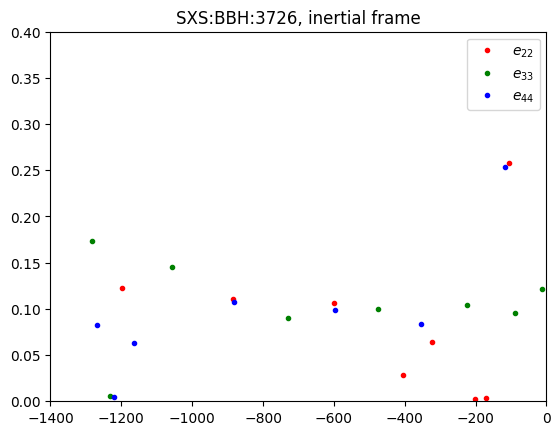

In [28]:
theta_22 = h_22.arg_unwrapped
theta_33 = h_33.arg_unwrapped
theta_44 = h_44.arg_unwrapped
theta_22 = theta_22 - theta_22[np.argmax(A)]
theta_33 = theta_33 - theta_33[np.argmax(A)]
theta_44 = theta_44 - theta_44[np.argmax(A)]

t22, ec22 = ecxxmaker(t01, theta_22.data, 22, 250, False)
t33, ec33 = ecxxmaker(t01, theta_33.data, 33, 250, False)
t44, ec44 = ecxxmaker(t01, theta_44.data, 44, 250, False)
# t22 = t22[:10]; ec22 = ec22[:10]
# t33 = t33[:11]; ec33 = ec33[:11]
# t44 = t44[1:11]; ec44 = ec44[1:11]
plt.plot(t22, ec22, 'r.', label=r"$e_{22}$")
plt.plot(t33, ec33, 'g.', label=r"$e_{33}$")
plt.plot(t44, ec44, 'b.', label=r"$e_{44}$")
plt.xlim(-1400, 0)
plt.ylim(0, 0.4)
plt.legend()
plt.title("SXS:BBH:3726, inertial frame")

What is that. For the co-precessing frame:

/tmp/ipykernel_2892/4016233564.py:4: RuntimeWarning: invalid value encountered in sqrt
  psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
/tmp/ipykernel_2892/4016233564.py:10: RuntimeWarning: invalid value encountered in sqrt
  theta = (1/3)*np.arctan((1242*np.sqrt(3)/iksi)*(np.sqrt(35266176 - 31184003*iksi**2 - 3675129*iksi**4)/(15712542 + 1225043*iksi**2)))
/tmp/ipykernel_2892/4016233564.py:11: RuntimeWarning: invalid value encountered in sqrt
  return (1/138)*(-107*iksi + np.sqrt(54648 + 11449*iksi)*np.cos(theta)-np.sqrt(163944 + 34347*iksi)*np.sin(theta))


(4,)
(4,)
(4,)


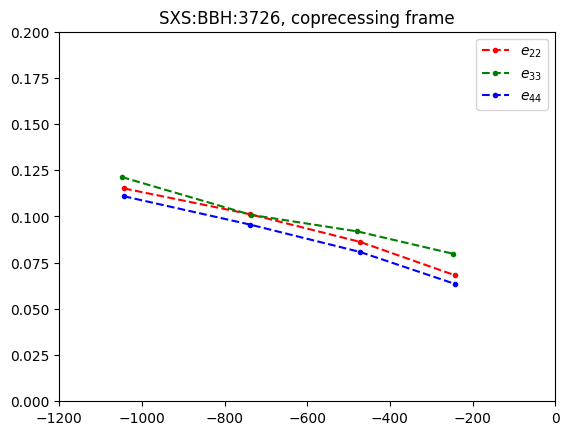

In [29]:
t2 = h_copr.t
h_22 = h_copr[:, h_copr.index(2, 2)]
h_2n2 = h_copr[:, h_copr.index(2, -2)]
h_33 = h_copr[:, h_copr.index(3, 3)]
h_3n3 = h_copr[:, h_copr.index(3, -3)]
h_44 = h_copr[:, h_copr.index(4, 4)]
h_4n4 = h_copr[:, h_copr.index(4, -4)]
A = h_22.abs
t_merger = t1[np.argmax(A)]
t01 = t2 - t_merger
theta_22 = 0.5*(h_22.arg_unwrapped-h_2n2.arg_unwrapped)
theta_33 = 0.5*(h_33.arg_unwrapped-h_3n3.arg_unwrapped)
theta_44 = 0.5*(h_44.arg_unwrapped-h_4n4.arg_unwrapped)
theta_22 = theta_22 - theta_22[np.argmax(A)]
theta_33 = theta_33 - theta_33[np.argmax(A)]
theta_44 = theta_44 - theta_44[np.argmax(A)]

t22, ec22 = ecxxmaker(t01, theta_22.data, 22, 250, False)
t33, ec33 = ecxxmaker(t01, theta_33.data, 33, 250, False)
t44, ec44 = ecxxmaker(t01, theta_44.data, 44, 250, False)
t22 = t22[1:5]; ec22 = ec22[1:5]
t33 = t33[1:5]; ec33 = ec33[1:5]
t44 = t44[3:7]; ec44 = ec44[3:7]
plt.plot(t22, ec22, 'r--.', label=r"$e_{22}$")
plt.plot(t33, ec33, 'g--.', label=r"$e_{33}$")
plt.plot(t44, ec44, 'b--.', label=r"$e_{44}$")
plt.xlim(-1200, 0)
plt.ylim(0, 0.2)
plt.legend()
plt.title("SXS:BBH:3726, coprecessing frame")
print(np.shape(ec22))
print(np.shape(ec33))
print(np.shape(ec44))

The question now becomes, when incorporating the energy flux, do I use the derivative of the original, inertial strain, or the derivative of the coprecessing frame strain?

As it turns out, $e_c$ measurements also work under the coprecessing frame treatment. The result is however a far cry from the $e_\mathrm{ref}$ value of 0.27.

I will be testing this with another waveform (with more orbits), comparing both with $e_\mathrm{gw}$ values and testing newer waveform models.

In [ ]:
#SXS:BBH:4290
